# Optimization Basics

In machine learning, we have a model with parameters (weights and biases).  
The model makes predictions, and a loss function measures how wrong those predictions are.

Our goal is to find parameter values that minimize the loss:

$$
\theta^* = \arg\min_{\theta} J(\theta)
$$

Where:
- $\theta$: model parameters
- $J(\theta)$: loss/objective function

---

## Gradient

The gradient tells us the direction of the steepest increase of the loss function.  
So, to minimize the loss, we move in the opposite direction of the gradient.

For a simple function:

$$
J(w) = w^2
$$

Its derivative is:

$$
\frac{dJ}{dw} = 2w
$$

---

## Gradient Descent Update Rule

The basic update rule is:

$$
w_{t+1} = w_t - \eta \frac{dJ}{dw}
$$

Or in vector form:

$$
\theta_{t+1} = \theta_t - \eta \nabla_{\theta} J(\theta_t)
$$

Where:
- $\eta$: learning rate
- $\nabla_{\theta} J(\theta_t)$: gradient at step $t$

---

## Learning Rate

The learning rate controls how big each update step is:
- Too small: learning is very slow
- Too large: optimization may overshoot or diverge


In [170]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

X = np.linspace(0, 10, 100)
y= 3* X + 2 + np.random.randn(100) * 2

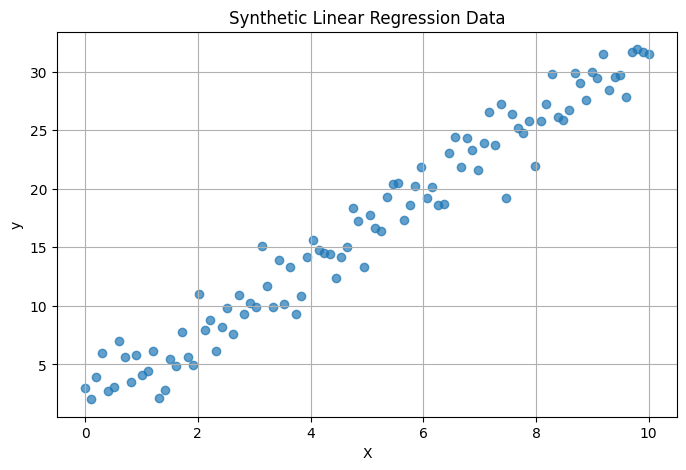

In [171]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.7)
plt.title("Synthetic Linear Regression Data")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True)
plt.show()

In [172]:
def predict(X, w, b):
    return w*X+b
def mse_loss(X, y, w, b):
    y_pred = predict(X, w, b)
    return np.mean((y_pred - y)** 2)
def compute_gradients(X, y, w, b):
    N = len(X)
    y_pred = predict(X, w, b)
    error = y_pred - y
    dw = (2/N) * np.sum(error*X)
    db = (2/N) * np.sum(error)
    return dw, db

In [173]:
def train_gradient_descent(X, y, w_init=0.0, b_init=0.0, lr=0.001, epochs=1000):
    w = w_init
    b = b_init
    loss_history = []
    param_history = []
    
    for epoch in range(epochs):
        dw, db = compute_gradients(X, y, w, b)
        w = w - lr * dw
        b = b - lr * db
        loss = mse_loss(X, y, w, b)
        
        loss_history.append(loss)
        param_history.append((w, b))
        
    return w, b, loss_history, param_history

In [174]:
w, b, loss_history, param_history = train_gradient_descent(X, y, w_init=0.0, lr=0.001, epochs=2000)
print("Learned w:", w)
print("Learned b:", b)
print("Final loss:", loss_history[-1])

Learned w: 3.0929029825386025
Learned b: 1.2199743956013245
Final loss: 3.3075137094297333


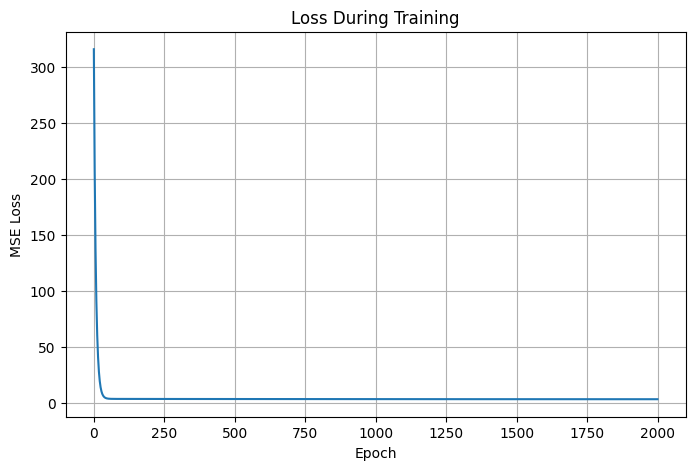

In [175]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.title("Loss During Training")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

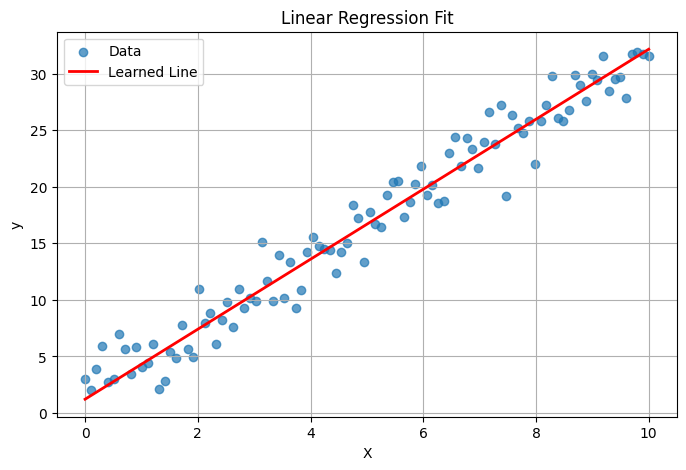

In [176]:
y_pred = predict(X, w, b)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data', alpha=0.7)
plt.plot(X, y_pred, color='red', label='Learned Line', linewidth=2)
plt.title("Linear Regression Fit")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


# Stochastic Gradient Descent (SGD)

Instead of computing gradients over the whole dataset, SGD updates the parameters using only one sample at a time.

For one sample $(x_i, y_i)$:

$$
\hat{y}_i = wx_i + b
$$

Sample loss:

$$
J_i(w,b) = (\hat{y}_i - y_i)^2
$$

Gradients:

$$
\frac{\partial J_i}{\partial w} = 2(\hat{y}_i-y_i)x_i
$$

$$
\frac{\partial J_i}{\partial b} = 2(\hat{y}_i-y_i)
$$

Update rule:

$$
w \leftarrow w - \eta \frac{\partial J_i}{\partial w}
$$

$$
b \leftarrow b - \eta \frac{\partial J_i}{\partial b}
$$


In [177]:
def train_sgd(X, y, lr=0.001, epochs=20, beta=0.9, seed=42, sgd_type="reg_sgd"):
    np.random.seed(seed)

    w = 0.0
    b = 0.0

    w_history = []
    b_history = []
    loss_history = []

    N = len(X)

    v_w = 0.0
    v_b = 0.0

    for epoch in range(epochs):
        indices = np.random.permutation(N)

        for i in indices:
            xi = X[i]
            yi = y[i]

            if sgd_type == "reg_sgd":
                # Gradient at current point
                y_pred = w * xi + b
                error = y_pred - yi

                dw = 2 * error * xi
                db = 2 * error

                w = w - lr * dw
                b = b - lr * db

            elif sgd_type == "Momentum":
                # Gradient at current point
                y_pred = w * xi + b
                error = y_pred - yi

                dw = 2 * error * xi
                db = 2 * error

                # Velocity is the actual update step
                v_w = beta * v_w - lr * dw
                v_b = beta * v_b - lr * db

                w = w + v_w
                b = b + v_b

            elif sgd_type == "Nesterov":
                # Lookahead point
                w_lookahead = w + beta * v_w
                b_lookahead = b + beta * v_b

                # Gradient at lookahead point
                y_pred = w_lookahead * xi + b_lookahead
                error = y_pred - yi

                dw = 2 * error * xi
                db = 2 * error

                # Velocity update
                v_w = beta * v_w - lr * dw
                v_b = beta * v_b - lr * db

                # Parameter update
                w = w + v_w
                b = b + v_b

            else:
                raise ValueError("sgd_type must be one of: 'reg_sgd', 'Momentum', 'Nesterov'")

        loss = mse_loss(X, y, w, b)
        loss_history.append(loss)
        w_history.append(w)
        b_history.append(b)

    return w, b, loss_history, w_history, b_history


In [178]:
w_sgd, b_sgd, sgd_loss_history,sgd_w_history, sgd_b_history = train_sgd(X, y, lr=0.001, epochs=50)

print("SGD learned w:", w_sgd)
print("SGD learned b:", b_sgd)
print("SGD final loss:", sgd_loss_history[-1])


SGD learned w: 3.080397779076947
SGD learned b: 1.5677447288964526
SGD final loss: 3.314810502724797


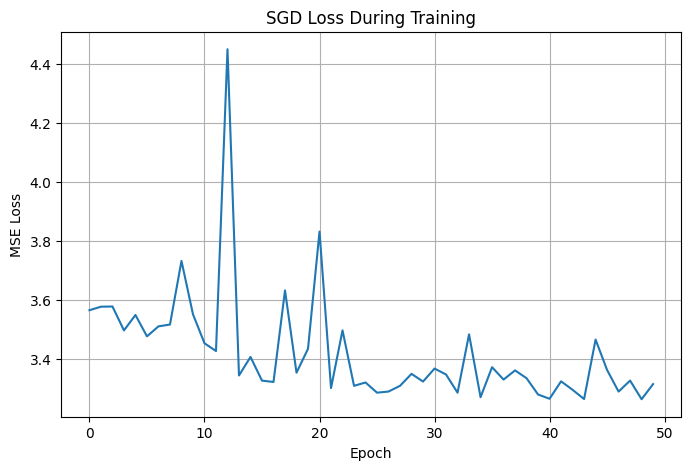

In [179]:
plt.figure(figsize=(8, 5))
plt.plot(sgd_loss_history)
plt.title("SGD Loss During Training")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()


# Momentum Optimizer from Scratch

## Why Momentum?

In plain SGD, parameters are updated using only the current gradient:

$$
\theta_{t+1} = \theta_t - \eta g_t
$$

where:

$$
g_t = \nabla_\theta J(\theta_t)
$$

Because SGD uses one sample or a mini-batch at each step, the gradient can be noisy.  
This often causes zigzag movement, especially in narrow valleys of the loss surface.

Momentum reduces this problem by accumulating a moving average of past gradients.

---

## Physical Intuition

Momentum is similar to a ball rolling down a hill.

A normal gradient descent step only looks at the current slope.  
Momentum also remembers the previous direction of movement.

As a result:

- oscillations in inconsistent directions are reduced
- movement in consistent directions is accelerated

---

## Momentum Formula

We define a velocity term:

$$
v_t = \beta v_{t-1} + (1-\beta)g_t
$$

Then update the parameters:

$$
\theta_{t+1} = \theta_t - \eta v_t
$$

where:

- $\eta$ is the learning rate
- $\beta$ is the momentum coefficient
- $g_t$ is the current gradient
- $v_t$ is the moving average of gradients

A common value is:

$$
\beta = 0.9
$$

---

## Momentum for Linear Regression

For the linear model:

$$
\hat{y} = wx + b
$$

and sample loss:

$$
L_i = (\hat{y}_i - y_i)^2
$$

the gradients are:

$$
dw = 2(\hat{y}_i - y_i)x_i
$$

$$
db = 2(\hat{y}_i - y_i)
$$

Momentum updates:

$$
v_w = \beta v_w + (1-\beta)dw
$$

$$
v_b = \beta v_b + (1-\beta)db
$$

$$
w = w - \eta v_w
$$

$$
b = b - \eta v_b
$$


In [180]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n_samples = 100
X = np.linspace(-5, 5, n_samples)
noise = np.random.randn(n_samples)*2.0
y= 3*X+2+noise

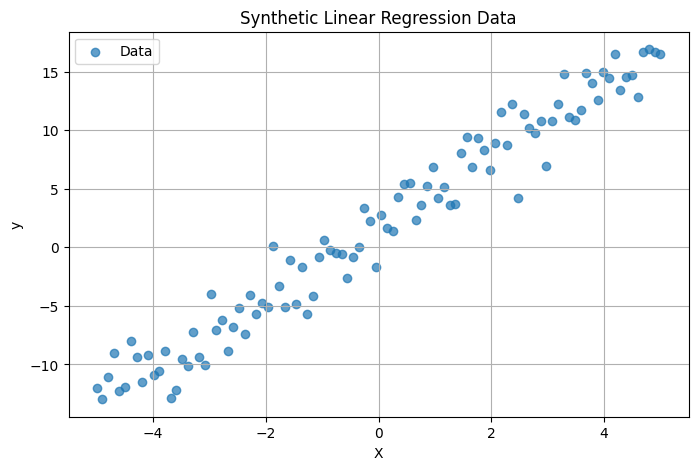

In [181]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.7, label="Data")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Linear Regression Data")
plt.legend()
plt.grid(True)
plt.show()


In [182]:
sgd_w, sgd_b, sgd_losses, sgd_w_hist, sgd_b_hist = train_sgd(
    X, y,
    lr=0.001,
    epochs=50,
    seed=42
)

mom_w, mom_b, mom_losses, mom_w_hist, mom_b_hist = train_sgd(X, y, lr=0.001, epochs=50,beta=0.5,seed=42, sgd_type="Momentum")

print("SGD:")
print("w =", sgd_w)
print("b =", sgd_b)
print("final loss =", sgd_losses[-1])

print("\nMomentum:")
print("w =", mom_w)
print("b =", mom_b)
print("final loss =", mom_losses[-1])




SGD:
w = 3.0446771797332612
b = 1.7901601015445177
final loss = 3.2621067210129784

Momentum:
w = 3.0546140049465067
b = 1.7858510417840627
final loss = 3.2658708779805443


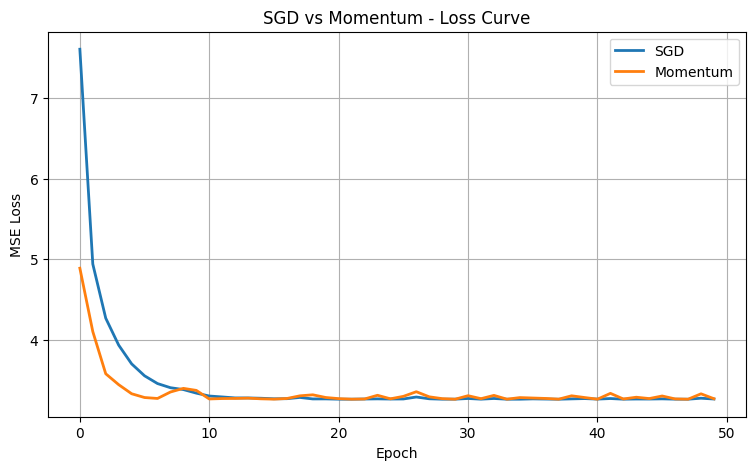

In [183]:
plt.figure(figsize=(9, 5))

plt.plot(sgd_losses, label="SGD", linewidth=2)
plt.plot(mom_losses, label="Momentum", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("SGD vs Momentum - Loss Curve")
plt.legend()
plt.grid(True)
plt.show()


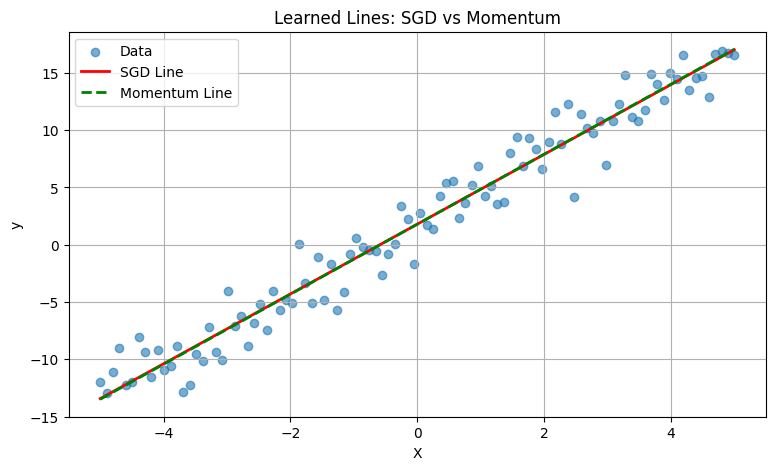

In [184]:
y_pred_sgd = predict(X, sgd_w, sgd_b)
y_pred_mom = predict(X, mom_w, mom_b)

plt.figure(figsize=(9, 5))

plt.scatter(X, y, alpha=0.6, label="Data")
plt.plot(X, y_pred_sgd, color="red", linewidth=2, label="SGD Line")
plt.plot(X, y_pred_mom, color="green", linewidth=2, linestyle="--", label="Momentum Line")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Learned Lines: SGD vs Momentum")
plt.legend()
plt.grid(True)
plt.show()


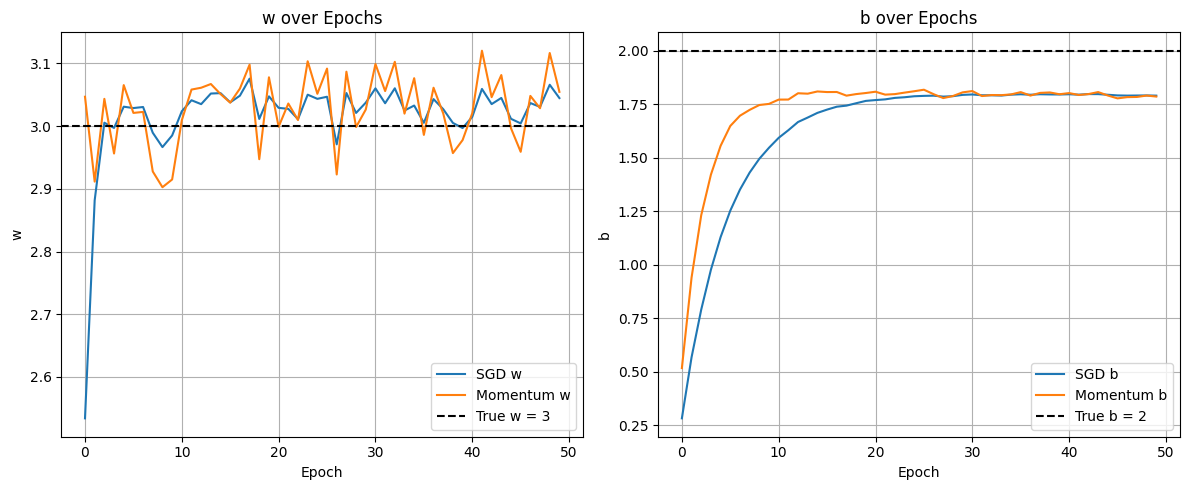

In [185]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(sgd_w_hist, label="SGD w")
plt.plot(mom_w_hist, label="Momentum w")
plt.axhline(3, color="black", linestyle="--", label="True w = 3")
plt.xlabel("Epoch")
plt.ylabel("w")
plt.title("w over Epochs")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(sgd_b_hist, label="SGD b")
plt.plot(mom_b_hist, label="Momentum b")
plt.axhline(2, color="black", linestyle="--", label="True b = 2")
plt.xlabel("Epoch")
plt.ylabel("b")
plt.title("b over Epochs")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


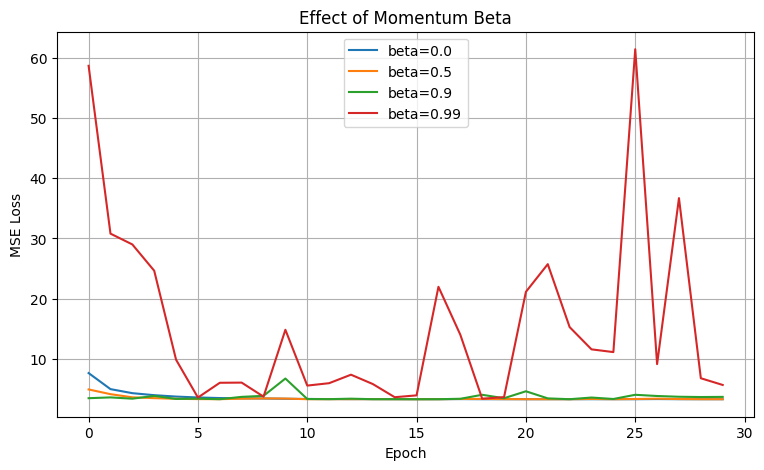

In [186]:
betas = [0.0, 0.5, 0.9, 0.99]

plt.figure(figsize=(9, 5))

for beta in betas:
    w_tmp, b_tmp, losses_tmp, _, _ = train_sgd(
        X, y,
        lr=0.001,
        epochs=30,
        beta=beta,
        seed=42,
        sgd_type="Momentum"
    )
    
    plt.plot(losses_tmp, label=f"beta={beta}")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Effect of Momentum Beta")
plt.legend()
plt.grid(True)
plt.show()


# Nesterov Momentum from Scratch

## Why Nesterov?

Standard Momentum improves SGD by accumulating a moving average of past gradients.  
However, it still computes the gradient at the current parameter position.

Nesterov Momentum goes one step further:  
it first makes a **lookahead step** using the current velocity,  
then computes the gradient at that future position.

This often gives a more accurate update direction.

---

## Intuition

Momentum says:

- use current gradient
- keep moving in the previous direction

Nesterov says:

- first look at where momentum is taking you
- compute the gradient there
- then correct your movement more intelligently

So instead of reacting late, Nesterov tries to anticipate the future position.

---

## Nesterov Formula

First compute the lookahead position:

$$
\theta_{\text{lookahead}} = \theta_t - \eta \beta v_{t-1}
$$

Then compute the gradient there:

$$
g_t = \nabla J(\theta_{\text{lookahead}})
$$

Update velocity:

$$
v_t = \beta v_{t-1} + (1-\beta) g_t
$$

Update parameters:

$$
\theta_{t+1} = \theta_t - \eta v_t
$$

where:

- $v_t$ is the velocity
- $\beta$ is the momentum coefficient
- $\eta$ is the learning rate

---

## Linear Regression Case

For the model:

$$
\hat{y} = wx + b
$$

sample loss:

$$
L_i = (\hat{y}_i - y_i)^2
$$

The lookahead parameters are:

$$
w_{\text{lookahead}} = w - \eta \beta v_w
$$

$$
b_{\text{lookahead}} = b - \eta \beta v_b
$$

Then compute prediction at the lookahead position:

$$
\hat{y}_i^{\text{lookahead}} = w_{\text{lookahead}} x_i + b_{\text{lookahead}}
$$

Error:

$$
error = \hat{y}_i^{\text{lookahead}} - y_i
$$

Gradients:

$$
dw = 2 \cdot error \cdot x_i
$$

$$
db = 2 \cdot error
$$

Velocity updates:

$$
v_w = \beta v_w + (1-\beta) dw
$$

$$
v_b = \beta v_b + (1-\beta) db
$$

Parameter updates:

$$
w = w - \eta v_w
$$

$$
b = b - \eta v_b
$$


In [187]:
lr_common = 0.0005
beta_common = 0.9
epochs_common = 200
seed_common = 42

sgd_w, sgd_b, sgd_losses, sgd_w_hist, sgd_b_hist = train_sgd(
    X, y,
    lr=lr_common,
    epochs=epochs_common,
    beta=beta_common,
    seed=seed_common,
    sgd_type="reg_sgd"
)

mom_w, mom_b, mom_losses, mom_w_hist, mom_b_hist = train_sgd(
    X, y,
    lr=lr_common,
    epochs=epochs_common,
    beta=beta_common,
    seed=seed_common,
    sgd_type="Momentum"
)

nes_w, nes_b, nes_losses, nes_w_hist, nes_b_hist = train_sgd(
    X, y,
    lr=lr_common,
    epochs=epochs_common,
    beta=beta_common,
    seed=seed_common,
    sgd_type="Nesterov"
)


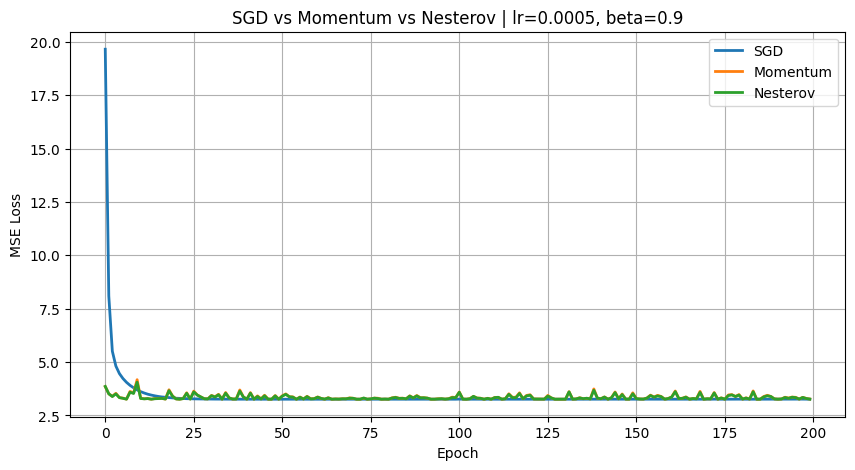

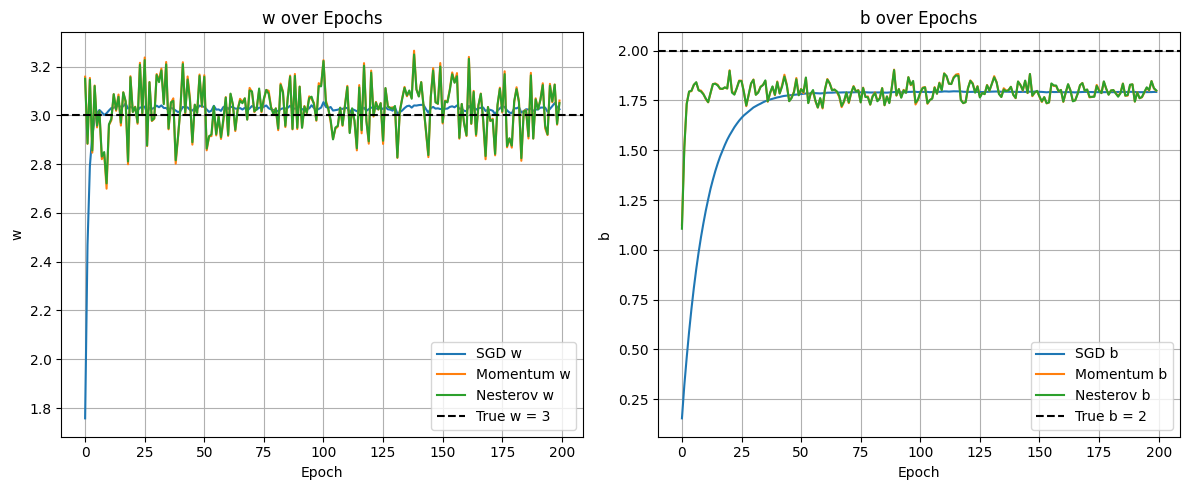

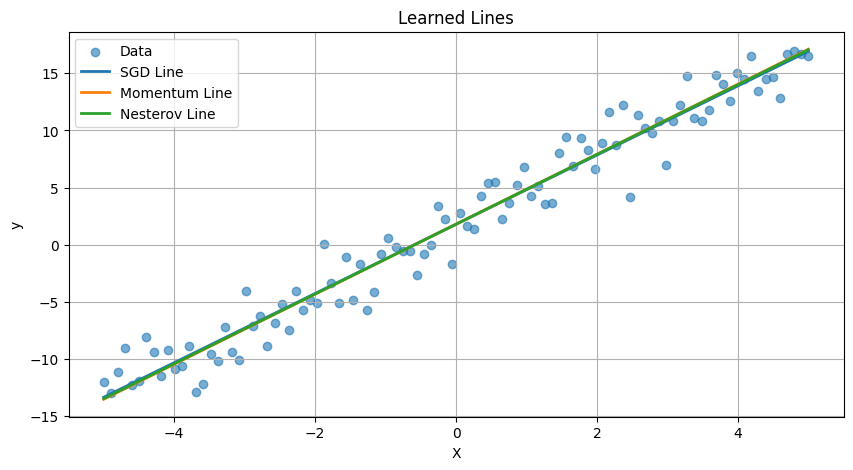

In [188]:
plt.figure(figsize=(10, 5))

plt.plot(sgd_losses, label="SGD", linewidth=2)
plt.plot(mom_losses, label="Momentum", linewidth=2)
plt.plot(nes_losses, label="Nesterov", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title(f"SGD vs Momentum vs Nesterov | lr={lr_common}, beta={beta_common}")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(sgd_w_hist, label="SGD w")
plt.plot(mom_w_hist, label="Momentum w")
plt.plot(nes_w_hist, label="Nesterov w")
plt.axhline(3, color="black", linestyle="--", label="True w = 3")
plt.xlabel("Epoch")
plt.ylabel("w")
plt.title("w over Epochs")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(sgd_b_hist, label="SGD b")
plt.plot(mom_b_hist, label="Momentum b")
plt.plot(nes_b_hist, label="Nesterov b")
plt.axhline(2, color="black", linestyle="--", label="True b = 2")
plt.xlabel("Epoch")
plt.ylabel("b")
plt.title("b over Epochs")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

y_pred_sgd = predict(X, sgd_w, sgd_b)
y_pred_mom = predict(X, mom_w, mom_b)
y_pred_nes = predict(X, nes_w, nes_b)

plt.figure(figsize=(10, 5))

plt.scatter(X, y, alpha=0.6, label="Data")
plt.plot(X, y_pred_sgd, label="SGD Line", linewidth=2)
plt.plot(X, y_pred_mom, label="Momentum Line", linewidth=2)
plt.plot(X, y_pred_nes, label="Nesterov Line", linewidth=2)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Learned Lines")
plt.legend()
plt.grid(True)
plt.show()


### Comparison: SGD vs Momentum vs Nesterov

In this experiment, we compare three optimization methods for training a simple linear regression model:

- `learning_rate = 0.0005`
- `beta = 0.9`
- `epochs = 200`

---

#### Loss Curve

The loss plot shows that **Momentum** and **Nesterov** reach a low MSE value faster than plain **SGD** during the early epochs.  
SGD decreases the loss more gradually, while Momentum-based methods move faster because they use information from previous gradients.

However, Momentum and Nesterov show slightly more fluctuations after reaching the low-loss region, mainly because the velocity term can cause overshooting around the optimum.

---

#### Parameter Updates: `w` and `b`

The parameter plots show that SGD approaches the true values more smoothly and gradually.  
In contrast, Momentum and Nesterov reach the neighborhood of the optimal parameters much faster, but they oscillate more around the target values.

This behavior is expected when using noisy sample-wise updates: Momentum-based methods accumulate past gradient directions, which can speed up convergence but may also amplify oscillations near the optimum.

---

#### Learned Regression Lines

The final learned lines are almost identical for all three methods.  
This means that although the optimizers follow different optimization paths, they eventually learn very similar linear models.

---

#### Summary

- **SGD**: slower but smoother convergence.
- **Momentum**: faster convergence, but with more oscillation.
- **Nesterov**: similar to Momentum in this simple problem, with a small lookahead effect.
- All three methods successfully learn a good linear regression line.


## Adagrad Optimizer

After comparing SGD, Momentum, and Nesterov Accelerated Gradient, we now examine Adagrad, an adaptive learning rate optimization method.

Unlike standard SGD, which uses the same learning rate for all parameters, Adagrad adjusts the learning rate separately for each parameter. It does this by accumulating the squared gradients of each parameter during training.

For parameters that receive large or frequent gradients, Adagrad reduces the effective learning rate over time. For parameters with smaller or less frequent gradients, the learning rate remains relatively larger. This makes Adagrad especially useful when different parameters require different update scales.

In linear regression, the model is defined as:

$$
\hat{y} = wx + b
$$

The mean squared error loss is:

$$
L = \frac{1}{n} \sum_{i=1}^{n}(\hat{y}_i - y_i)^2
$$

The gradients are:

$$
\frac{\partial L}{\partial w} = 2(\hat{y} - y)x
$$

$$
\frac{\partial L}{\partial b} = 2(\hat{y} - y)
$$

Adagrad keeps track of the accumulated squared gradients:

$$
G_w = G_w + \left(\frac{\partial L}{\partial w}\right)^2
$$

$$
G_b = G_b + \left(\frac{\partial L}{\partial b}\right)^2
$$

Then the parameters are updated as:

$$
w = w - \frac{\eta}{\sqrt{G_w} + \epsilon} \frac{\partial L}{\partial w}
$$

$$
b = b - \frac{\eta}{\sqrt{G_b} + \epsilon} \frac{\partial L}{\partial b}
$$

Here, $\eta$ is the initial learning rate and $\epsilon$ is a very small value added to avoid division by zero.

Because the denominator grows over time, Adagrad gradually decreases the effective learning rate. This can make training more stable, but it may also slow down learning too much in later epochs.


In [189]:
def adagrad_optimizer(X, y, lr=0.1, epochs=200, epsilon=1e-8):
    w= np.random.randn()
    b= np.random.randn()
    
    G_w = 0
    G_b = 0
    
    loss_history=[]
    w_history=[]
    b_history=[]
    
    n = len(X)
    for epoch in range(epochs):
        for i in range(n):
            xi = X[i]
            yi = y[i]
            
            # prediction
            y_pred = w*xi+b
            
            # gradients for one sample
            error = y_pred - yi
            dw = 2* error*xi
            db = 2* error
            
            # accumulate squared gradients
            G_w += dw ** 2
            G_b += db ** 2
            
            # Adagrad
            w -= (lr/ (np.sqrt(G_w) + epsilon))* dw
            b -= (lr/ (np.sqrt(G_b)+ epsilon))* db
        # mse loss
        y_pred_all = w* X+b
        loss = np.mean((y_pred_all-y)**2)
        
        loss_history.append(loss)
        w_history.append(w)
        b_history.append(b)
        
    return w, b, loss_history, w_history, b_history

In [190]:
w_adagrad, b_adagrad, loss_adagrad, w_hist_adagrad, b_hist_adagrad = adagrad_optimizer(
    X, y,
    lr=0.1,
    epochs=200,
    epsilon=1e-8
)

print("Adagrad Results:")
print("w:", w_adagrad)
print("b:", b_adagrad)
print("Final Loss:", loss_adagrad[-1])


Adagrad Results:
w: 3.0289395897790774
b: 1.7874532108247179
Final Loss: 3.259657977450061


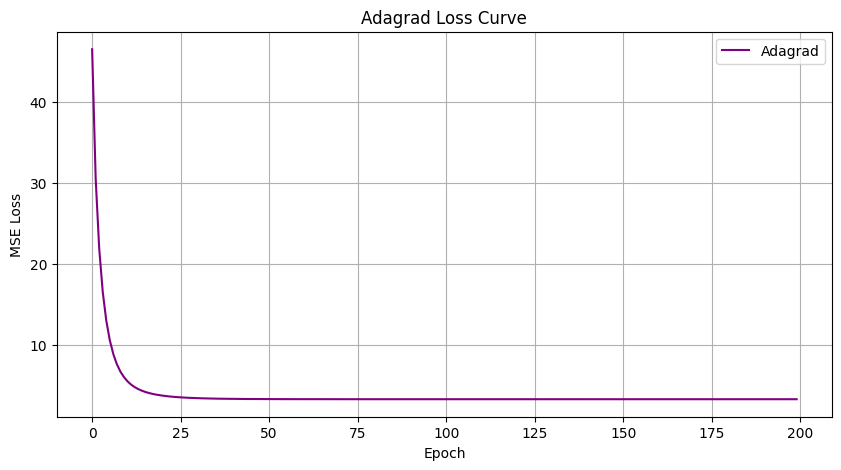

In [191]:
plt.figure(figsize=(10, 5))
plt.plot(loss_adagrad, label="Adagrad", color="purple")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Adagrad Loss Curve")
plt.legend()
plt.grid(True)
plt.show()


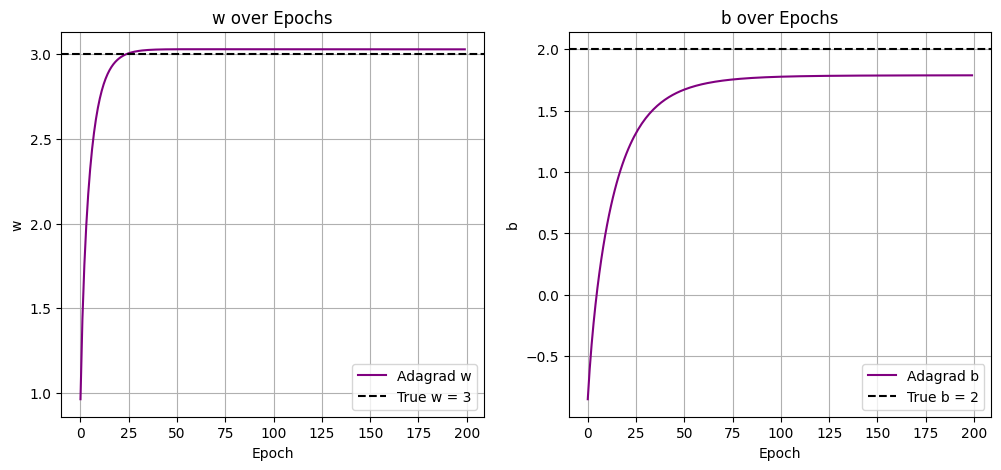

In [192]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(w_hist_adagrad, label="Adagrad w", color="purple")
plt.axhline(y=3, color="black", linestyle="--", label="True w = 3")
plt.xlabel("Epoch")
plt.ylabel("w")
plt.title("w over Epochs")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(b_hist_adagrad, label="Adagrad b", color="purple")
plt.axhline(y=2, color="black", linestyle="--", label="True b = 2")
plt.xlabel("Epoch")
plt.ylabel("b")
plt.title("b over Epochs")
plt.legend()
plt.grid(True)

plt.show()


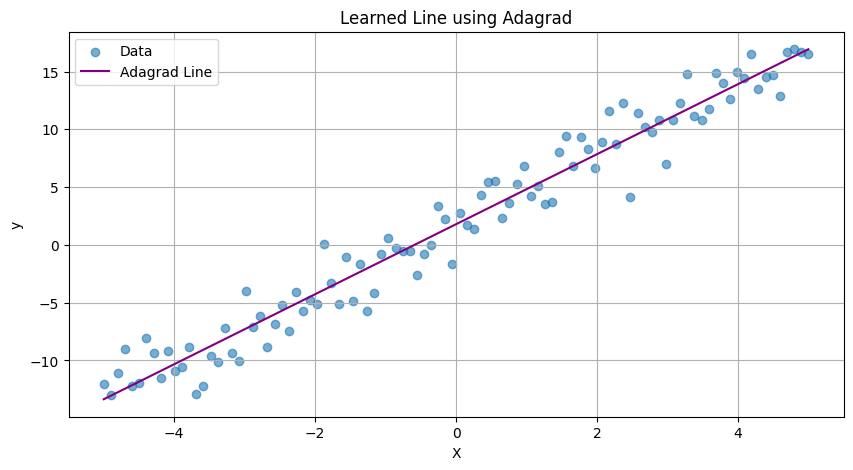

In [193]:
plt.figure(figsize=(10, 5))

plt.scatter(X, y, label="Data", alpha=0.6)

y_pred_adagrad = w_adagrad * X + b_adagrad
plt.plot(X, y_pred_adagrad, color="purple", label="Adagrad Line")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Learned Line using Adagrad")
plt.legend()
plt.grid(True)
plt.show()


### Adagrad Optimizer

Adagrad adapts the learning rate separately for each parameter based on the history of squared gradients. Parameters with large or frequent gradients receive smaller effective learning rates over time, while parameters with smaller gradients can still make relatively larger updates.

In this experiment, Adagrad converges by gradually reducing its step sizes as training progresses. This can make the optimization more stable, especially near the minimum. However, because the accumulated squared gradients continuously increase, the effective learning rate may become very small, which can slow down learning in later epochs.

Compared to Momentum-based methods, Adagrad usually shows less oscillation, but it may also converge more slowly after the initial updates due to its aggressive learning rate decay.


## RMSProp Optimizer

RMSProp is an adaptive learning rate optimization algorithm designed to improve one limitation of Adagrad. In Adagrad, the accumulated squared gradients keep growing during training, which can make the effective learning rate become extremely small.

RMSProp solves this problem by using an exponentially weighted moving average of squared gradients instead of a simple cumulative sum. This means that recent gradients have more influence, while older gradients gradually lose their effect.

For linear regression, the model is:

$$
\hat{y} = wx + b
$$

The gradients are:

$$
\frac{\partial L}{\partial w} = 2(\hat{y} - y)x
$$

$$
\frac{\partial L}{\partial b} = 2(\hat{y} - y)
$$

RMSProp keeps a moving average of squared gradients:

$$
S_w = \rho S_w + (1 - \rho)\left(\frac{\partial L}{\partial w}\right)^2
$$

$$
S_b = \rho S_b + (1 - \rho)\left(\frac{\partial L}{\partial b}\right)^2
$$

Then the parameters are updated as:

$$
w = w - \frac{\eta}{\sqrt{S_w} + \epsilon} \frac{\partial L}{\partial w}
$$

$$
b = b - \frac{\eta}{\sqrt{S_b} + \epsilon} \frac{\partial L}{\partial b}
$$

Here, $\eta$ is the learning rate, $\rho$ is the decay rate, and $\epsilon$ is a small value used to avoid division by zero.

Compared to Adagrad, RMSProp usually performs better because its learning rate does not shrink forever. It can adapt to the recent behavior of gradients and often converges faster and more reliably.


In [194]:
def rmsprop_optimizer(X, y, lr=0.01, rho=0.9, epochs=200, epsilon=1e-8):
    # Initialize parameters
    w = np.random.randn()
    b = np.random.randn()

    # Moving averages of squared gradients
    S_w = 0
    S_b = 0

    loss_history = []
    w_history = []
    b_history = []

    n = len(X)

    for epoch in range(epochs):
        for i in range(n):
            xi = X[i]
            yi = y[i]

            # Prediction
            y_pred = w * xi + b

            # Error
            error = y_pred - yi

            # Gradients
            dw = 2 * error * xi
            db = 2 * error

            # Exponentially weighted average of squared gradients
            S_w = rho * S_w + (1 - rho) * (dw ** 2)
            S_b = rho * S_b + (1 - rho) * (db ** 2)

            # Parameter update
            w -= (lr / (np.sqrt(S_w) + epsilon)) * dw
            b -= (lr / (np.sqrt(S_b) + epsilon)) * db

        # Compute loss after each epoch
        y_pred_all = w * X + b
        loss = np.mean((y_pred_all - y) ** 2)

        loss_history.append(loss)
        w_history.append(w)
        b_history.append(b)

    return w, b, loss_history, w_history, b_history


In [195]:
w_rmsprop, b_rmsprop, loss_rmsprop, w_hist_rmsprop, b_hist_rmsprop = rmsprop_optimizer(
    X, y,
    lr=0.01,
    rho=0.9,
    epochs=200,
    epsilon=1e-8
)

print("RMSProp Results:")
print("w:", w_rmsprop)
print("b:", b_rmsprop)
print("Final Loss:", loss_rmsprop[-1])


RMSProp Results:
w: 3.0684604223755487
b: 1.7222831853596305
Final Loss: 3.27872573123587


## Adam Optimizer

Adam stands for **Adaptive Moment Estimation**. It is one of the most widely used optimization algorithms in machine learning and deep learning because it combines the strengths of **Momentum** and **RMSProp**.

Adam keeps track of two moving averages for each parameter:

1. **First moment (mean of gradients)** → helps smooth the update direction, similar to Momentum.
2. **Second moment (mean of squared gradients)** → helps adapt the learning rate for each parameter, similar to RMSProp.

This makes Adam both **stable** and **fast**, especially when gradients are noisy or when different parameters require different step sizes.

We assume the linear model is:

$$
\hat{y} = wx + b
$$

For the sample loss:

$$
L_i = (\hat{y}_i - y_i)^2
$$

the gradients are:

$$
\frac{\partial L}{\partial w} = 2(\hat{y}_i - y_i)x_i
$$

$$
\frac{\partial L}{\partial b} = 2(\hat{y}_i - y_i)
$$

Adam updates two running estimates for each parameter:

### 1. First Moment Estimate

This is the exponentially weighted moving average of the gradients:

$$
m_w = \beta_1 m_w + (1 - \beta_1)\frac{\partial L}{\partial w}
$$

$$
m_b = \beta_1 m_b + (1 - \beta_1)\frac{\partial L}{\partial b}
$$

Here, $\beta_1$ is usually chosen close to 1, with a common default value:

$$
\beta_1 = 0.9
$$

A larger $\beta_1$ means smoother momentum.

### 2. Second Moment Estimate

This is the exponentially weighted moving average of the squared gradients:

$$
v_w = \beta_2 v_w + (1 - \beta_2)\left(\frac{\partial L}{\partial w}\right)^2
$$

$$
v_b = \beta_2 v_b + (1 - \beta_2)\left(\frac{\partial L}{\partial b}\right)^2
$$

The usual default value is:

$$
\beta_2 = 0.999
$$

A larger $\beta_2$ makes the estimate of gradient magnitude more stable.

### Bias Correction

Since both $m$ and $v$ start at zero, they are biased toward zero during the first iterations. Adam corrects this using:

$$
\hat{m}_w = \frac{m_w}{1 - \beta_1^t}
\qquad
\hat{m}_b = \frac{m_b}{1 - \beta_1^t}
$$

$$
\hat{v}_w = \frac{v_w}{1 - \beta_2^t}
\qquad
\hat{v}_b = \frac{v_b}{1 - \beta_2^t}
$$

where $t$ is the current timestep.

These corrected values are especially important at the beginning of training.

### Parameter Update Rule

Finally, the parameters are updated as follows:

$$
w = w - \frac{\eta}{\sqrt{\hat{v}_w} + \epsilon}\hat{m}_w
$$

$$
b = b - \frac{\eta}{\sqrt{\hat{v}_b} + \epsilon}\hat{m}_b
$$

where:

- $\eta$ is the learning rate
- $\epsilon$ is a very small constant such as $10^{-8}$, added for numerical stability

### Why Adam Works Well

Adam is popular because it provides:

- **Momentum-like behavior** through the first moment estimate
- **Adaptive learning rates** through the second moment estimate
- **Faster convergence** in many practical problems
- **More stable updates** when gradients vary a lot

In short, Adam tries to move in a good direction like Momentum, while also scaling the step size like RMSProp.

### Summary

Adam combines two key ideas:

- **Momentum** → smooths the gradient direction
- **RMSProp** → adjusts the step size based on gradient history

Because of this, Adam is often a strong default optimizer for many machine learning tasks.


In [196]:
def adam_optimizer(X, y, lr=0.01, beta1=0.9, beta2=0.999, epochs=200, epsilon=1e-8):
    w= np.random.randn()
    b= np.random.randn()
    
    m_w = 0
    m_b = 0
    v_w = 0
    v_b = 0
    loss_history = []
    w_history = []
    b_history = []
    
    n = len(X)
    t=0
    
    for epoch in range(epochs):
        for i in range(n):
            t+=1
            xi =X[i]
            yi =y[i]
            
            y_pred = w*xi+b
            error = y_pred - yi
            
            dw = 2*error*xi
            db = 2*error
            
            # first moment estimate
            m_w = beta1 * m_w + (1-beta1) * dw
            m_b = beta1 * m_b + (1-beta1) * db
            
            # second moment estimate
            v_w = beta2 * v_w + (1-beta2) * (dw**2)
            v_b = beta2 * v_b + (1-beta2) * (db**2)
            
            # bias correction
            m_w_hat = m_w / (1-beta1**t)
            m_b_hat = m_b / (1-beta1**t)
            
            v_w_hat = v_w / (1-beta2**t)
            v_b_hat = v_b / (1-beta2**t)
            
            w -= (lr/(np.sqrt(v_w_hat)+ epsilon))* m_w_hat
            b -= (lr/(np.sqrt(v_b_hat)+ epsilon))* m_b_hat
            
            
        y_pred_all = w* X +b
        loss = np.mean((y_pred_all - y)**2)
        
        loss_history.append(loss)
        w_history.append(w)
        b_history.append(b)
        
    return w, b, loss_history, w_history, b_history

In [197]:
w_adam, b_adam, loss_adam, w_hist_adam, b_hist_adam = adam_optimizer(
    X, y,
    lr=0.01,
    beta1=0.9,
    beta2=0.999,
    epochs=200,
    epsilon=1e-8
)

print("Adam Results:")
print("w:", w_adam)
print("b:", b_adam)
print("Final Loss:", loss_adam[-1])


Adam Results:
w: 3.0500660992554436
b: 1.7429892147593613
Final Loss: 3.2663472572296137


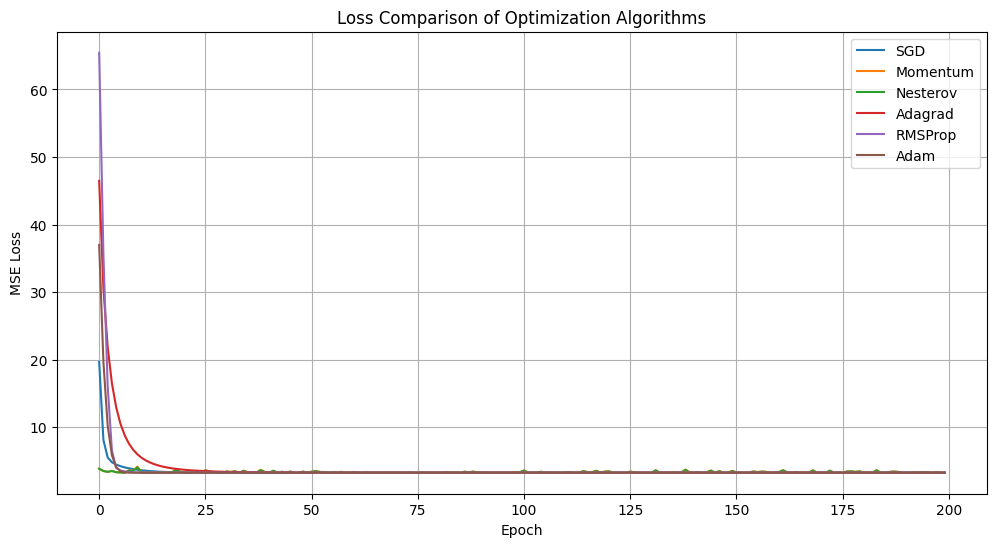

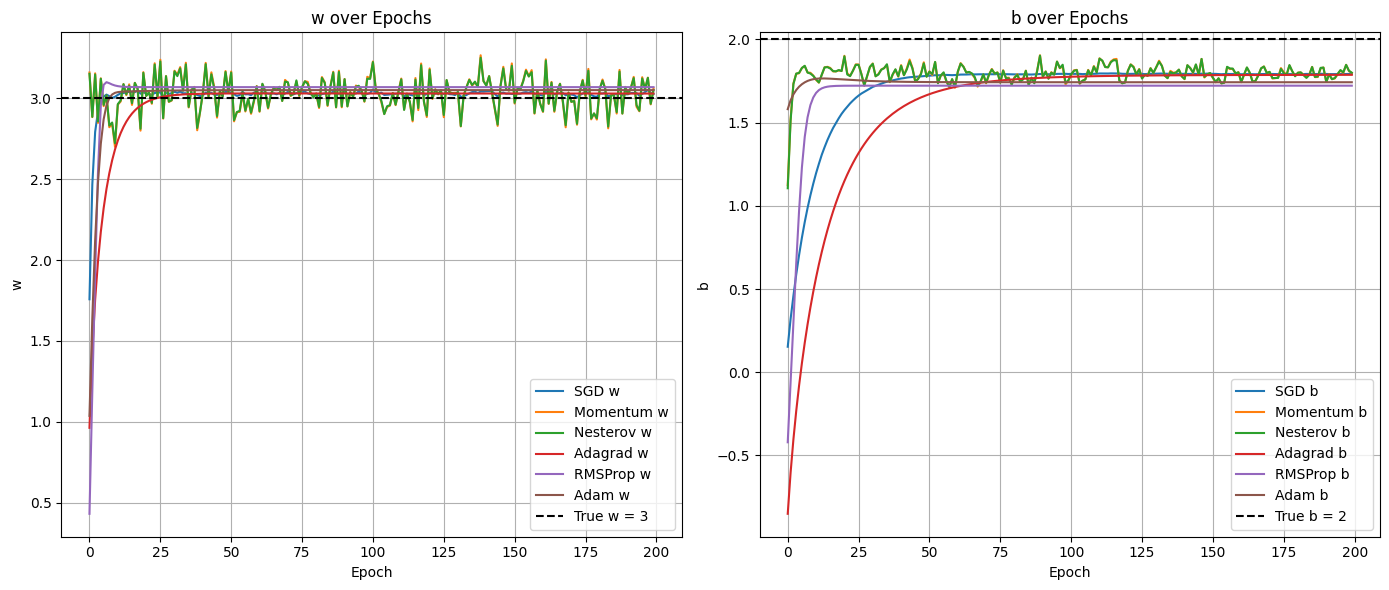

In [198]:
plt.figure(figsize=(12, 6))


plt.plot(sgd_losses, label="SGD")
plt.plot(mom_losses, label="Momentum")
plt.plot(nes_losses, label="Nesterov")
plt.plot(loss_adagrad, label="Adagrad")
plt.plot(loss_rmsprop, label="RMSProp")
plt.plot(loss_adam, label="Adam")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss Comparison of Optimization Algorithms")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(14, 6))

# =========================
# w over epochs
# =========================

plt.subplot(1, 2, 1)

plt.plot(sgd_w_hist, label="SGD w")
plt.plot(mom_w_hist, label="Momentum w")
plt.plot(nes_w_hist, label="Nesterov w")

plt.plot(w_hist_adagrad, label="Adagrad w")
plt.plot(w_hist_rmsprop, label="RMSProp w")
plt.plot(w_hist_adam, label="Adam w")

plt.axhline(3, color="black", linestyle="--", label="True w = 3")

plt.xlabel("Epoch")
plt.ylabel("w")
plt.title("w over Epochs")
plt.legend()
plt.grid(True)


# =========================
# b over epochs
# =========================

plt.subplot(1, 2, 2)

plt.plot(sgd_b_hist, label="SGD b")
plt.plot(mom_b_hist, label="Momentum b")
plt.plot(nes_b_hist, label="Nesterov b")

plt.plot(b_hist_adagrad, label="Adagrad b")
plt.plot(b_hist_rmsprop, label="RMSProp b")
plt.plot(b_hist_adam, label="Adam b")

plt.axhline(2, color="black", linestyle="--", label="True b = 2")

plt.xlabel("Epoch")
plt.ylabel("b")
plt.title("b over Epochs")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


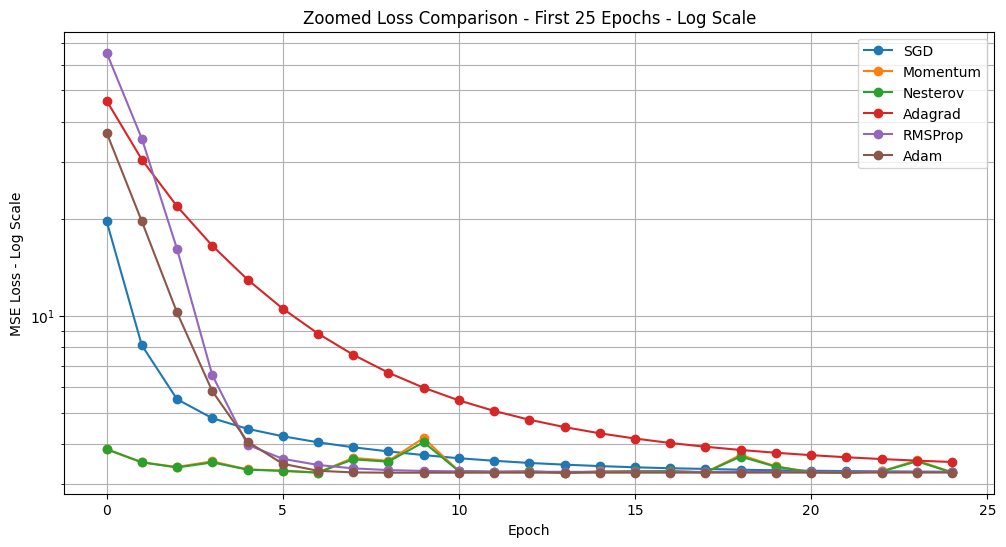

In [203]:
zoom_epochs = 25

plt.figure(figsize=(12, 6))

plt.plot(sgd_losses[:zoom_epochs], marker="o", label="SGD")
plt.plot(mom_losses[:zoom_epochs], marker="o", label="Momentum")
plt.plot(nes_losses[:zoom_epochs], marker="o", label="Nesterov")
plt.plot(loss_adagrad[:zoom_epochs], marker="o", label="Adagrad")
plt.plot(loss_rmsprop[:zoom_epochs], marker="o", label="RMSProp")
plt.plot(loss_adam[:zoom_epochs], marker="o", label="Adam")

plt.yscale("log")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss - Log Scale")
plt.title("Zoomed Loss Comparison - First 25 Epochs - Log Scale")
plt.legend()
plt.grid(True, which="both")
plt.show()


In [199]:
print("Final Parameters:")
print("-----------------")
print(f"SGD:       w = {sgd_w_hist[-1]:.4f}, b = {sgd_b_hist[-1]:.4f}, loss = {sgd_losses[-1]:.4f}")
print(f"Momentum:  w = {mom_w_hist[-1]:.4f}, b = {mom_b_hist[-1]:.4f}, loss = {mom_losses[-1]:.4f}")
print(f"Nesterov:  w = {nes_w_hist[-1]:.4f}, b = {nes_b_hist[-1]:.4f}, loss = {nes_losses[-1]:.4f}")
print(f"Adagrad:   w = {w_hist_adagrad[-1]:.4f}, b = {b_hist_adagrad[-1]:.4f}, loss = {loss_adagrad[-1]:.4f}")
print(f"RMSProp:   w = {w_hist_rmsprop[-1]:.4f}, b = {b_hist_rmsprop[-1]:.4f}, loss = {loss_rmsprop[-1]:.4f}")
print(f"Adam:      w = {w_hist_adam[-1]:.4f}, b = {b_hist_adam[-1]:.4f}, loss = {loss_adam[-1]:.4f}")


Final Parameters:
-----------------
SGD:       w = 3.0254, b = 1.7928, loss = 3.2597
Momentum:  w = 3.0611, b = 1.7988, loss = 3.2692
Nesterov:  w = 3.0505, b = 1.8004, loss = 3.2642
Adagrad:   w = 3.0289, b = 1.7875, loss = 3.2597
RMSProp:   w = 3.0685, b = 1.7223, loss = 3.2787
Adam:      w = 3.0501, b = 1.7430, loss = 3.2663


## Overall Optimizer Performance Analysis

In this experiment, several optimization algorithms were compared on a simple Linear Regression problem:

$$
y = wx + b
$$

The goal was to observe how different optimizers update the model parameters $w$ and $b$, how fast they reduce the loss, and how stable their convergence behavior is.

The compared optimizers are:

- SGD
- Momentum
- Nesterov Accelerated Gradient
- Adagrad
- RMSProp
- Adam

---

## Loss Behavior

From the overall loss curve, all optimizers eventually converge to almost the same final loss value. This is expected because the problem is convex and relatively simple. However, the important difference appears in the **early epochs**, especially in the first 25 epochs.

The zoomed log-scale loss plot shows that:

- **RMSProp and Adam** reduce the loss very quickly in the first few epochs.
- **SGD** also converges fast and remains relatively stable.
- **Momentum and Nesterov** start close to the optimum and show small oscillations because the updates contain accumulated velocity.
- **Adagrad** decreases the loss more slowly compared to RMSProp and Adam at the beginning, but it still converges reliably.

Using a log-scale plot is useful here because the initial loss drop is very sharp. Without log scale, many early differences between optimizers become visually compressed.

---

## Parameter Convergence: w and b

The parameter plots show how each optimizer moves toward the true values:

$$
w = 3,\quad b = 2
$$

For parameter $w$:

- Most optimizers quickly approach the true value $w = 3$.
- SGD, Momentum, RMSProp, Adam, and Adagrad converge smoothly near the correct value.
- Nesterov shows more visible oscillation around the optimum. This is likely caused by noisy sample-wise updates and the lookahead mechanism.

For parameter $b$:

- All optimizers move toward the true value $b = 2$, but most of them converge slightly below it.
- This small gap can happen because of noise in the generated data and because the training process uses stochastic updates.
- Adagrad reaches the region more slowly compared to adaptive methods like RMSProp and Adam.

---

## Stability and Oscillation

Although Momentum and Nesterov are often expected to reduce zigzag movement, in this experiment Nesterov shows stronger oscillations in the parameter path.

This behavior is understandable because:

- The training is based on stochastic/sample-wise updates.
- Gradients are noisy.
- Momentum-based methods accumulate past gradients, which can amplify noise.
- Nesterov evaluates the gradient at a lookahead position, and if the velocity is not well matched with the learning rate, oscillations can become more visible.

Therefore, in noisy settings, Momentum and Nesterov do not always look smoother than plain SGD.

---

## Key Observations

| Optimizer | Speed | Stability | Notes |
|---|---:|---:|---|
| SGD | Good | Good | Simple and stable for this convex problem |
| Momentum | Fast | Medium | Can oscillate due to accumulated velocity |
| Nesterov | Fast | Lower in this run | More zigzag due to noisy updates |
| Adagrad | Medium | Good | Learning rate decays over time, can become slow |
| RMSProp | Very Fast | Good | Strong early loss reduction |
| Adam | Very Fast | Good | Combines momentum and adaptive scaling effectively |

---

## Conclusion

All optimizers successfully learned the linear relationship in the data. Since this is a simple convex regression problem, their final results are very close. The main difference is not the final loss, but the path they take to reach the solution.

Adaptive optimizers such as **RMSProp** and **Adam** show faster early convergence. **SGD** performs surprisingly well and remains stable. **Nesterov** shows more oscillation in this particular experiment, mainly because stochastic updates introduce noise that can be amplified by velocity-based methods.

This experiment demonstrates that the best optimizer depends not only on the algorithm itself, but also on:

- learning rate
- noise level
- batch size
- initialization
- curvature of the loss surface
- stochasticity of gradient updates
